# RAG Embeddings Search and Vector Visualization

This notebook demonstrates how to retrieve similar books using the FAISS index, plot high-dimensional book descriptions in 2D space, and test the Gemini Chatbot generation.

In [1]:
import os
import sys
import django

# Setup Django environment
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../ai-service'))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'recommender_ai_service.settings')

# Configure database connection details for local development outside Docker
os.environ['DB_HOST'] = '127.0.0.1'
os.environ['DB_NAME'] = 'bookstore_ai'

# Allow synchronous operations in Jupyter's async context
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'

django.setup()

AI-Service background bootstrap sync will start in 15 seconds...

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from app.models import ProductNode
from app.rag_engine import RAGEngine

# 1. Initialize RAG Engine
rag = RAGEngine.get_instance()
products = list(ProductNode.objects.all())
print(f"Loaded {len(products)} products from Database.")

Initializing SentenceTransformer encoder...


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


FAISS index successfully rebuilt with 12 items!
Loaded 12 products from Database.


Projecting high-dimensional embeddings to 2D using PCA...


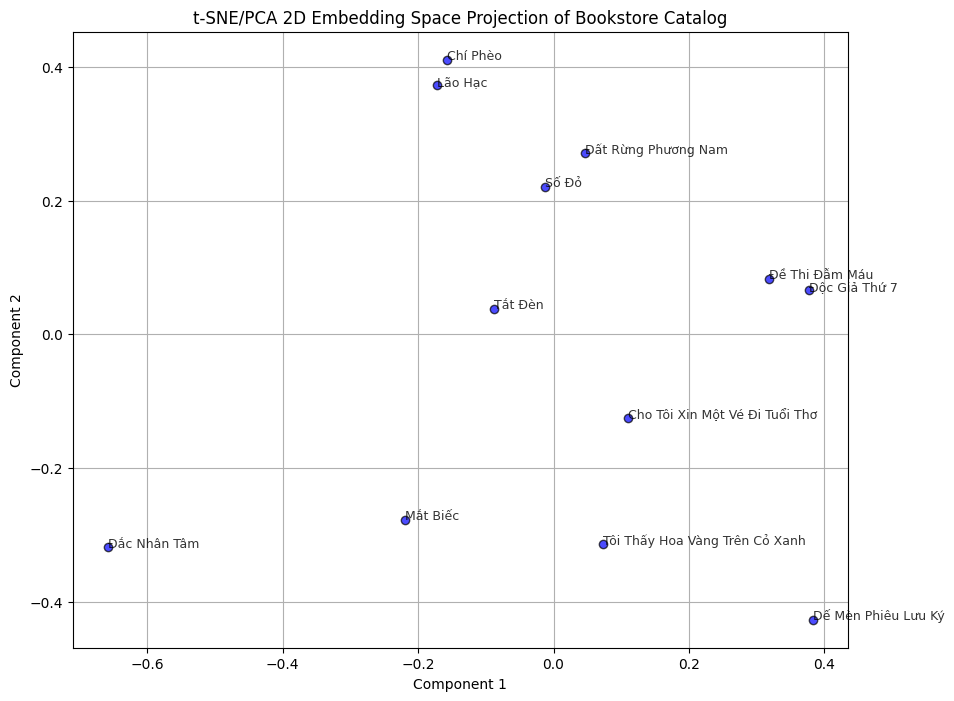

In [3]:
# 2. Vector space representation projection using PCA/t-SNE
print("Projecting high-dimensional embeddings to 2D using PCA...")
texts = [f"{p.title} - {p.author}" for p in products]
embeddings = rag.encoder.encode(texts)

# Use PCA to project embeddings to 2D
pca = PCA(n_components=2)
projected = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(projected[:, 0], projected[:, 1], c='blue', edgecolors='k', alpha=0.7)
for i, p in enumerate(products):
    plt.annotate(p.title, (projected[i, 0], projected[i, 1]), fontsize=9, alpha=0.8)
plt.title('t-SNE/PCA 2D Embedding Space Projection of Bookstore Catalog')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

In [4]:
# 3. Test RAG Search Query
query = "Tìm sách của Nguyễn Nhật Ánh"
matches = rag.search(query, k=3)
print(f"Search query: '{query}'")
print("========================")
for idx, (p, dist) in enumerate(matches):
    print(f"{idx+1}. Book: {p.title} (Author: {p.author}) | L2 Distance: {dist:.4f}")

Syncing 24 products from catalog...


FAISS index successfully rebuilt with 24 items!
Search query: 'Tìm sách của Nguyễn Nhật Ánh'
1. Book: Tôi Thấy Hoa Vàng Trên Cỏ Xanh (Author: Nguyễn Nhật Ánh) | L2 Distance: 0.7099
2. Book: Cho Tôi Xin Một Vé Đi Tuổi Thơ (Author: Nguyễn Nhật Ánh) | L2 Distance: 0.7720
3. Book: Mắt Biếc (Author: Nguyễn Nhật Ánh) | L2 Distance: 0.7753


In [5]:
# 4. Test RAG QA Chatbot answer generation
response = rag.generate_chatbot_answer(query)
print(f"Chatbot Prompt Query: {query}")
print("--------------------------------")
print("Chatbot Response:")
print(response)

Chatbot Prompt Query: Tìm sách của Nguyễn Nhật Ánh
--------------------------------
Chatbot Response:
Chào bạn! Rất tiếc hiện tại khóa kết nối AI (GEMINI_API_KEY) chưa được thiết lập. Tuy nhiên, dựa vào kho sách của chúng tôi, tôi tìm thấy một số gợi ý cho bạn:
- [Sách - ID: 10] "Tôi Thấy Hoa Vàng Trên Cỏ Xanh" của tác giả Nguyễn Nhật Ánh (Thể loại: General, Giá: 125000.00 VND)
- [Sách - ID: 9] "Cho Tôi Xin Một Vé Đi Tuổi Thơ" của tác giả Nguyễn Nhật Ánh (Thể loại: General, Giá: 95000.00 VND)
- [Sách - ID: 8] "Mắt Biếc" của tác giả Nguyễn Nhật Ánh (Thể loại: General, Giá: 110000.00 VND)
- [Sách - ID: 5] "Đất Rừng Phương Nam" của tác giả Đoàn Giỏi (Thể loại: General, Giá: 72000.00 VND)
